# Characterization of Continuous Transcriptional Heterogeneity in High-Risk Blastemal-Type Wilms' Tumors Using Unsupervised Machine Learning 
Author: Yaron Trink



In this notebook we will reproduce some of the figures from the paper "Characterization of Continuous Transcriptional Heterogeneity in High-Risk Blastemal-Type Wilms' Tumors Using Unsupervised Machine Learning".

This paper introduces an unsupervised machine learning approach to characterize transcriptional heterogeneity in high-risk blastemal-type Wilms' tumors, using a combination of archetype analysis and generative topic modeling.
The location of gene expression archetypes in latent (PCA) space was computed using the ParTI method from the Alon Lab (https://github.com/AlonLabWIS/ParTI)



In [1]:
import os
os.chdir(r'C:\Users\trinkya\OneDrive - Bar Ilan University\github\paper1_unsupervised\src\figure_1')
print('figure_1' in os.getcwd()) # this should be figure 1

import wilms_module_1 as wilms
import matplotlib.pyplot as plt
import pandas as pd
import collections
import numpy as np
from itertools import cycle

from importlib import reload
from typing import List, Dict, Literal, Optional


True


### Load Data

Selected genes from fetal kidney development, and metadata for all samples.
The dkfz mapping was provided by the Gessler lab.

In [2]:
selectedGenes= pd.read_csv('../data/selected_genes.csv')
metadata = pd.read_excel('../data/ordered_metadata_gessler.xlsx',index_col=0,header=4)
metadata.head()

,Exome,RNAseq,mRNA array,miRNA array,sex,age (months),bilateral / relapse,histological type,stage,metastasis at diagosis,...,active disease,follow-up < 2 yrs,mutation,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,dkfz
WT nr,,,,,,,,,,,,,,,,,,,,,
WT055,NaN,NaN,x,x,female,101.0,NaN,necrotic,3,y,...,y,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1079
WT056,NaN,NaN,x,x,male,124.0,NaN,regressive,3,y,...,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1080
WT057,NaN,NaN,x,x,female,41.0,NaN,stromal,1,-,...,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1081
WT058,NaN,NaN,x,x,female,35.0,NaN,mixed,2,-,...,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1082
WT059,NaN,NaN,x,x,female,43.0,NaN,blastemal,3,-,...,-,y,"SIX2 c.A530G, p.Q177R (het)",NaN,NaN,NaN,NaN,NaN,NaN,1083


In [3]:
metadata.columns

Index(['Exome', 'RNAseq', 'mRNA array', 'miRNA array', 'sex', 'age (months)',
       'bilateral / relapse', 'histological type ', 'stage',
       'metastasis at diagosis', 'relapse / metastasis', 'death',
       'active disease', 'follow-up < 2 yrs', 'mutation', 'Unnamed: 16',
       'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20',
       'Unnamed: 21', 'dkfz'],
      dtype='object')

Read normalized counts matrix for all samples and three archetypes.

In [4]:
dfExpression = pd.read_csv('../data/geneExpression_dkfz_arcs.csv',index_col=0)
dfExpression.head()

,GSM1287918_dkfz1079_CEL_gz,GSM1287919_dkfz1080_CEL_gz,GSM1287920_dkfz1081_CEL_gz,GSM1287921_dkfz1082_CEL_gz,GSM1287922_dkfz1083_CEL_gz,GSM1287923_dkfz1084_CEL_gz,GSM1287924_dkfz1085_CEL_gz,GSM1287925_dkfz1086_CEL_gz,GSM1287926_dkfz1087_CEL_gz,GSM1287927_dkfz1088_CEL_gz,...,GSM1287961_dkfz1242_CEL_gz,GSM1287962_dkfz1243_CEL_gz,GSM1287963_dkfz1244_CEL_gz,GSM1287964_dkfz1245_CEL_gz,GSM1287966_dkfz1248_CEL_gz,GSM1287969_dkfz1252_CEL_gz,GSM1287970_dkfz1253_CEL_gz,Arc1_Stromal,Arc2_Epi,Arc3_Blast
Row,,,,,,,,,,,,,,,,,,,,,
A1CF,6.363189,6.230602,5.922347,7.864022,6.098523,5.833497,6.274949,9.600060,6.076582,6.478255,...,6.407456,7.063916,5.856304,5.878194,6.694177,6.432702,6.062255,5.728897,8.725049,5.603684
A2M,11.642535,12.580059,11.893461,12.204555,10.357035,11.812267,8.325191,11.874214,12.016551,12.134039,...,10.118516,8.755689,11.952168,10.580123,11.700177,9.461577,10.897230,13.405186,12.082144,8.301283
A4GALT,6.959608,6.732352,6.417027,6.335210,6.426955,6.347637,6.649937,7.070676,6.566580,6.756439,...,6.478890,6.820080,6.456481,6.574614,6.679425,6.434237,6.433400,6.519046,6.923252,6.457928
A4GNT,5.432587,5.581830,5.327537,5.458090,5.517068,5.209767,5.622918,5.409845,5.500290,5.501198,...,5.412382,5.614335,5.383486,5.426760,5.640356,5.765432,5.502525,5.352079,5.471343,5.460456
AAAS,6.860649,7.066158,6.778449,6.830148,7.038568,6.715213,7.130071,7.042751,6.671875,6.923104,...,7.160326,7.022712,6.862959,7.030560,6.970308,7.267597,6.952854,6.737893,6.777730,7.169583


## Part 1: Pareto Task Inference
After preprocessing and data standardization, we performed principal components analysis (PCA) and found that the tumors form a triangle-shaped continuum in latent space, rather than discrete separated clusters (Figure 1A–F). Following the principle of Pareto task inference (see https://www.weizmann.ac.il/mcb/alon/download/pareto-task-inference-parti-method), we assume that the vertexes of this triangle-shaped geometric configuration represent “idealized” tumor components or cellular “archetypes” from which all the tumors within the triangle are composed. The location of a tumor in the continuum bounded by the archetypes indicates its relative composition of these idealized components. 

In [5]:
res = wilms.run_pca_on_normalized_counts(
    dfExpression,
    n_components=3,
    n_arcs=3,                         
    exclude_archetypes_from_pca=False, 
    center=False,
    scale=False,
    log1p=False,
    random_state=0
)

PC = res["PC"]                                
explained = res["explained_variance_ratio"]   
arcs = res["archetype_cols"]    

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'PCA (2D)'}, xlabel='PC1', ylabel='PC2'>)

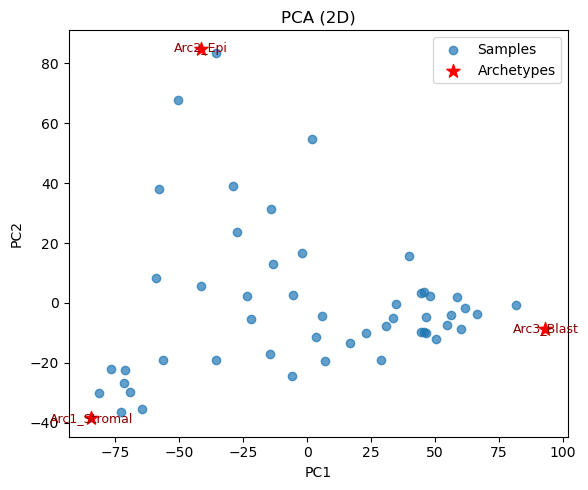

In [6]:
wilms.plot_pca2d(res, save_to_file=False, folder="results", file_end="wilms_pca", file_type="svg")


To identify the archetypes, the size and color of each sample (dot) are drawn according to expression levels of known genes marking the cell populations of the fetal developing kidney (large red—high expression; small blue—low expression).
It can be seen than FN1, a marker for the un-induced mesenchyme, is highly expressed towards the stromal archetype. Likewise, SLC12A1, which marks the renal epithelium, is highly expressed near the epithelial archetype, and SIX2, a marker for the cap mesenchyme, is predominantly expressed near the blastemal archetype. The genes TOP2A and MKI67, which mark cycling cells, are also highly expressed near the blastemal archetype.

(<Figure size 600x500 with 2 Axes>,
 <Axes: title={'center': 'MKI67'}, xlabel='PC1', ylabel='PC2'>)

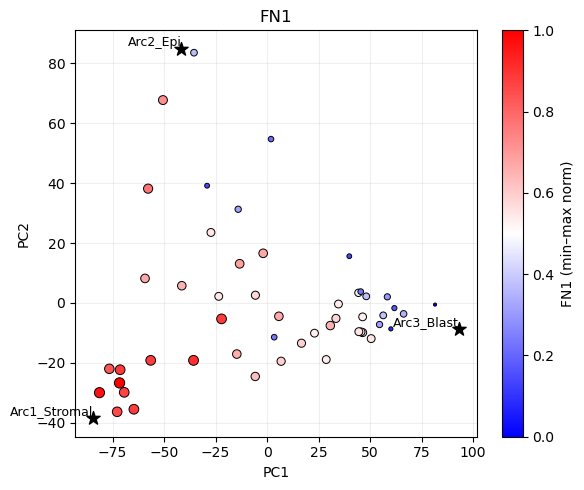

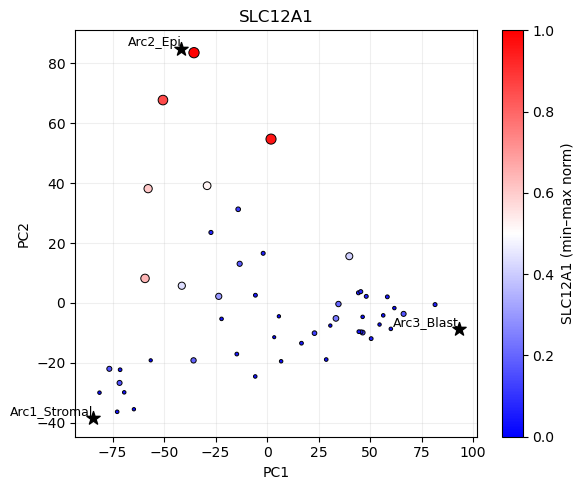

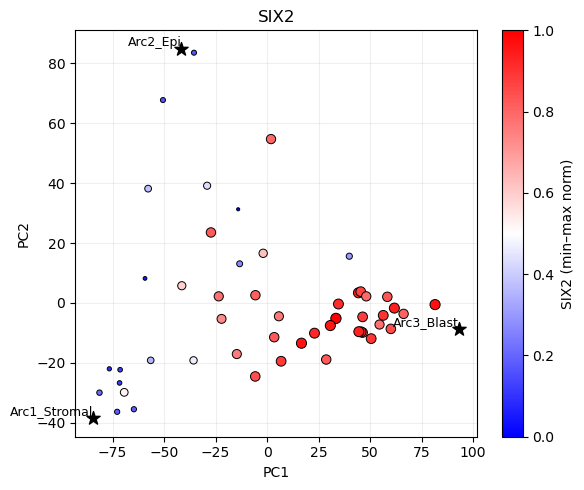

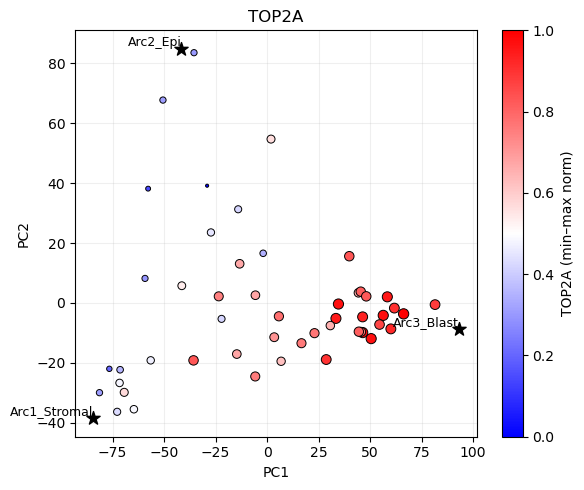

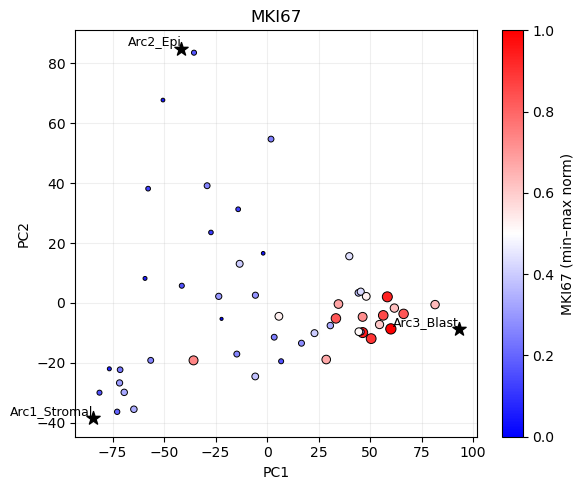

In [7]:

genes_to_plot = ["FN1", "SLC12A1", "SIX2","TOP2A", "MKI67"]

wilms.plot_gene_expression2d(
    pca_result=res,
    counts=dfExpression,
    genes=genes_to_plot,
    save_to_file=False
)

A PCA plot of the tumors marked according to their reported histological type. It can be seen that tumors with anaplastic histology (diffuse or focal), which is considered least favorable, tend to cluster in the vicinity of the blastemal archetype

Saved: results/plots\pca2d_by_subtype.svg


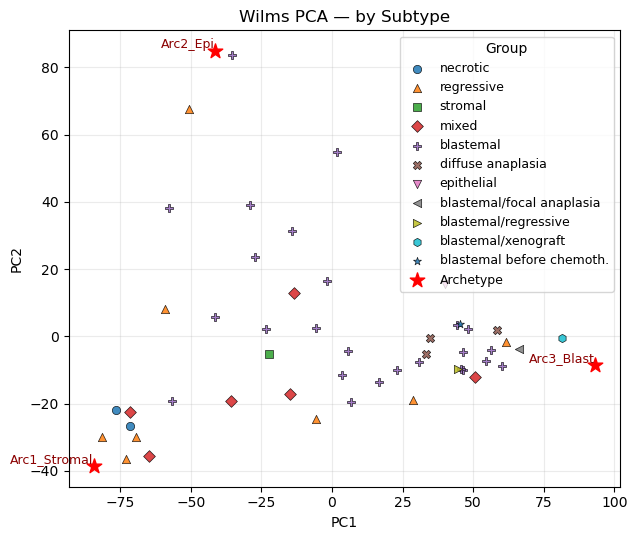

In [8]:
sample_list = metadata.loc[:,'histological type '].tolist()

fig, ax = wilms.plot_categorical_pca2d(
    pca_result=res,
    labels=sample_list,                   
    save_to_file=True,
    folder="results/plots",
    file_end="pca2d_by_subtype",
    file_type="svg",
    title="Wilms PCA — by Subtype"
)


### characterization of archetypes using GO enrichment analysis

For each of the three archetypes, we found a list of genes that are over-expressed (log2FC > 2) with respect to both of the other two archetypes. We found that the stromal archetype is enriched for genes typical to the un-induced mesenchyme, for example, components of the extracellular matrix (Figure 2D). The blastemal archetype is enriched for genes involved in maintenance of nephron progenitors and the mesenchymal to epithelial transition (MET), which are characteristic of the cap mesenchyme. Finally, genes enriched in the epithelial archetype are involved in cell–cell junctions, transport, and renal epithelial differentiation, which are typical to the early epithelial structures in the developing kidney.



In [9]:
samples = ["Arc1_Stromal",'Arc2_Epi','Arc3_Blast']

# Up-regulated genes where sample > ALL others by > 1 log2FC
res_all = wilms.diff_expression_one_vs_all(
    counts=dfExpression,
    samples=samples,
    threshold=2.0,               
    direction="both",              
    mode="pairwise_all",           
    save_path=None  
)

res_all['Arc1_Stromal']['up'][:5]


['ABCA1', 'ABCG1', 'ACKR3', 'ACP5', 'ACTA2']

## part 2 - topic modeling

We have seen that:
1) the tumors form a triangle-shaped continuum in latent space, rather than discrete separated clusters
2) the vertexes of this triangle-shaped geometric configuration represent “idealized” tumor components or cellular “archetypes” from which all the tumors within the triangle are composed.

To model the tumor composition with more quantitative rigor, we fit a generative topic model to the gene expression counts. This allows us to model each tumor as a distribution over latent topics. This approach is analogous to modeling documents as mixtures of topics in natural language processing, where each topic is characterized by a distribution over words. For example, a document may contain 30% of topic A, 50% of topic B, and 20% of topic C, with each topic representing a distinct theme or subject matter (sports,politics, technology etc). In our case, the topics will be biological themes. 
For more on topic modeling: https://www.cs.columbia.edu/~blei/papers/Blei2012.pdf


Choosing the appropriate number of topics is a critical step in topic modeling, albeit one that lacks a definitive solution. However, we have already seen that three archetypes can effectively capture the transcriptional heterogeneity in our dataset. This observation motivates our choice of three topics. 
The identity of the topics is usually inferred by examining which gene is most likely to be generated from each topic (P(topic|gene)). 


Topic modeling was run using the fastTopics R package. Here we'll examine some of the outputs, and see how they allow us to characterize tumor heterogeneity in terms of biological themes.


In [13]:
# custom scripts for topic modeling analysis and plotting

from fast_topics_analysis import (
    load_topic_model,
    plot_topic_simplex_2d,
    compute_posterior,
    plot_simplex_with_pca,
    plot_posterior_2d,
    get_high_posterior_genes,
    plot_simplex_with_pca_single
)

from pathlib import Path
from sklearn.decomposition import PCA

In [14]:
genes = list(pd.read_csv("../data/selected_genes.csv")["selected_genes"])

counts = pd.read_csv("../data/geneExpression_dkfz_arcs.csv", index_col=0)
model = load_topic_model(
    omega_path="../data/fastTopics_output/omega_3.csv",
    theta_path="../data/fastTopics_output/theta_3.csv",
    algo="fastTopics"
)


Each sample is modeled as a multinomial distribution over three topics, with each topic itself a multinomial distribution over genes.

In [15]:
print(model['omega'].head()) # distribution of topics in each sample
print(model['theta'].head() ) # distribution of genes in each topic

                                  k1        k2        k3
GSM1287918_dkfz1079_CEL_gz  0.135485  0.557651  0.306864
GSM1287919_dkfz1080_CEL_gz  0.118753  0.558801  0.322446
GSM1287920_dkfz1081_CEL_gz  0.191623  0.353996  0.454381
GSM1287921_dkfz1082_CEL_gz  0.280264  0.282216  0.437520
GSM1287922_dkfz1083_CEL_gz  0.122269  0.142530  0.735201
              k1        k2        k3
A1CF    0.000108  0.000056  0.000056
A2M     0.000121  0.000171  0.000085
A4GALT  0.000075  0.000068  0.000068
A4GNT   0.000058  0.000055  0.000058
AAAS    0.000071  0.000068  0.000077


We can visualize each sample in this new latent space. We can see that some samples are dominated by a single topic, while others are mixtures of two or three topics.

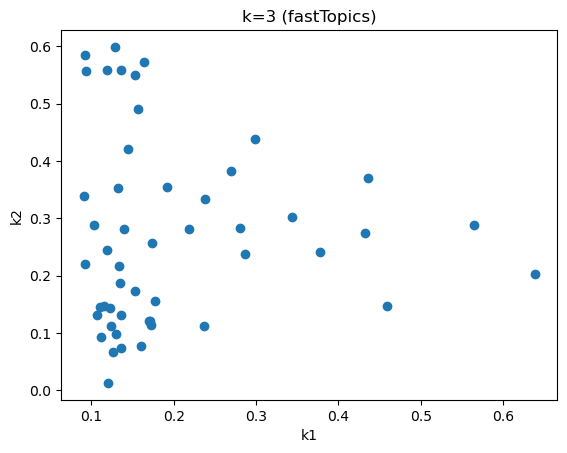

In [16]:
plot_topic_simplex_2d(
    model=model,
    x_axis="k1",
    y_axis="k2",
    save=False
)


We can compute the posterior distribution P(topic|gene) - given the expression of a particular gene, what is the probability that it came from each of the topics?. This allows us to identify which genes are most strongly associated with each topic, and thus infer the biological themes represented by each topic.

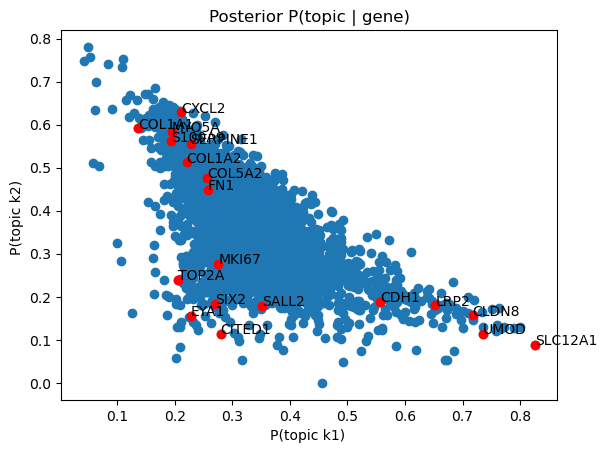

In [17]:
posterior = compute_posterior(model)

postGenes = [
    "SLC12A1", "UMOD", "LRP2", "CITED1", "EYA1", "TOP2A", "MKI67",
    "SIX2", "MYO5A", "COL1A1", "COL1A2", "CLDN8", "CDH1", "FN1",
    "COL5A2", "SERPINE1", "CXCL2", "SALL2", "S100A9"
]

plot_posterior_2d(
    posterior=posterior,
    topic1="k1",
    topic2="k2",
    selected_genes=postGenes,
    save=False
)

We see, for example, that the gene SLC12A1 is dominated by topic 1. This suggests that this topic has a strong epithelial component, and that samples with a high proportion of topic 1 are likely to have a significant epithelial component.

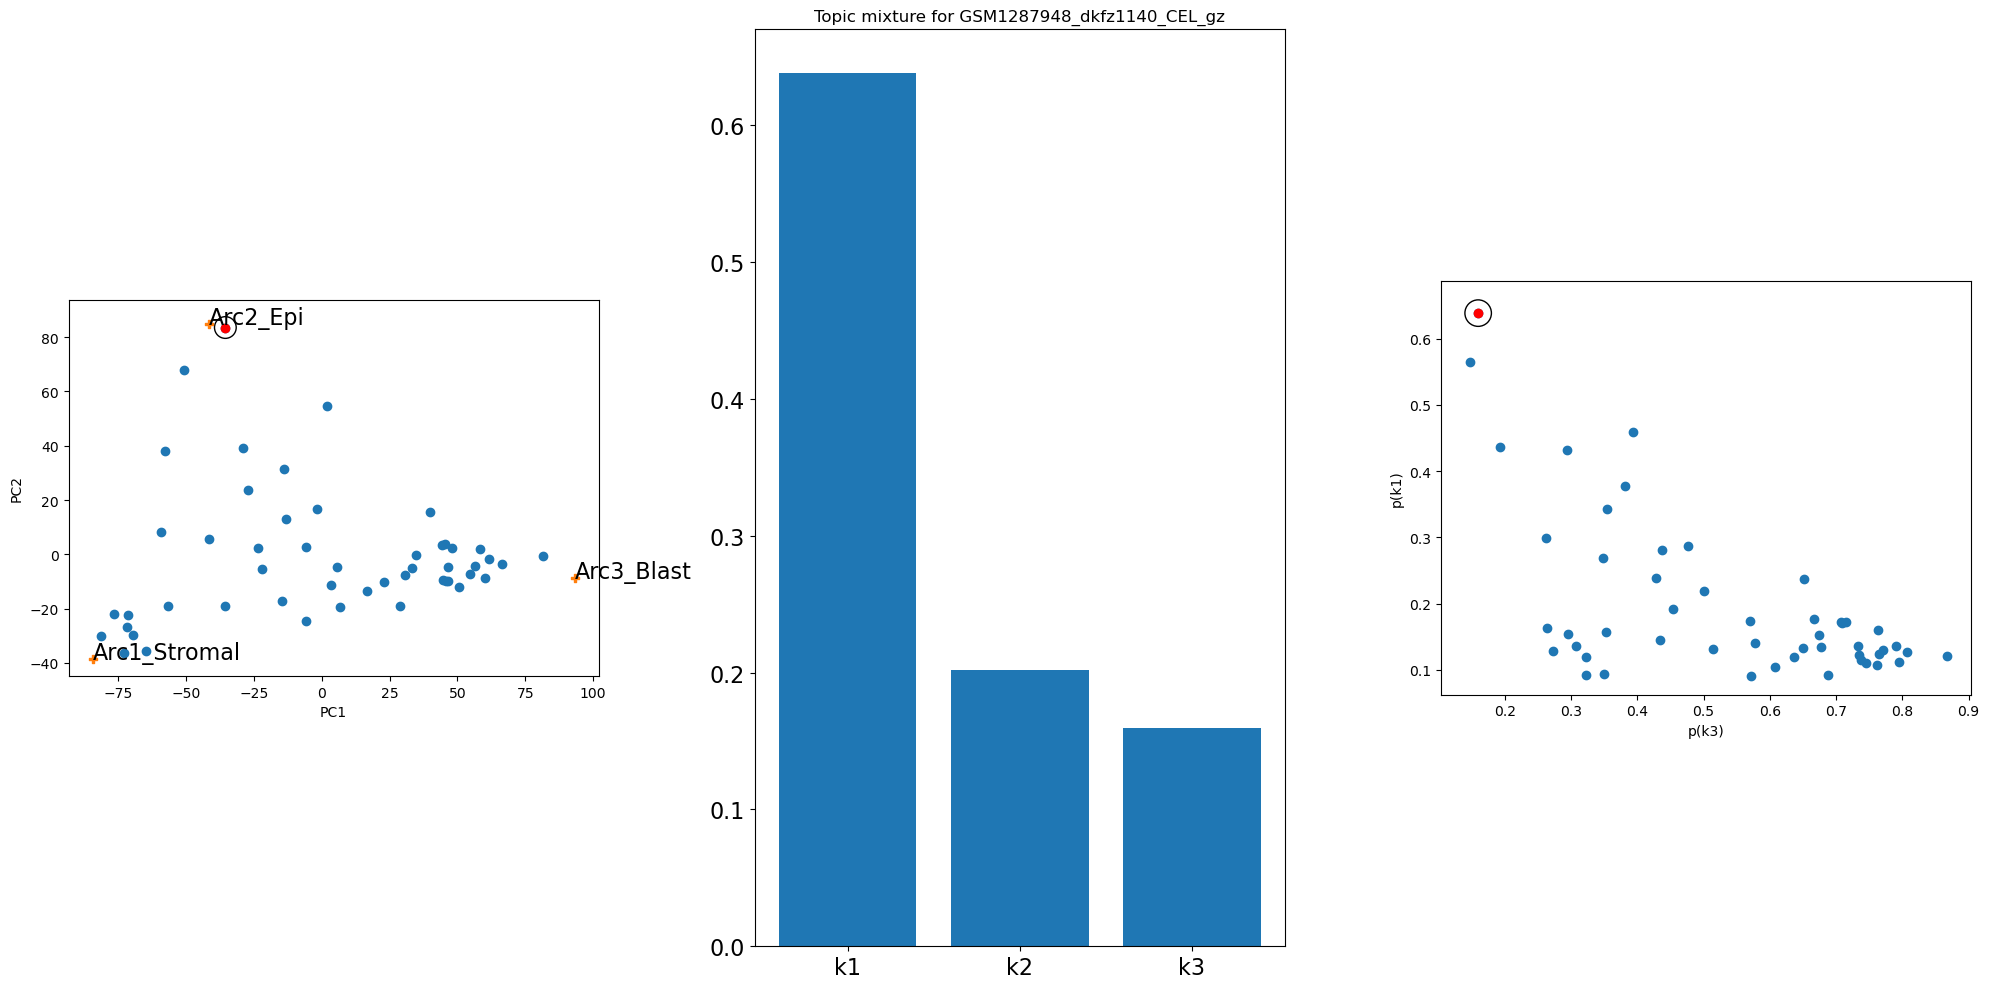

In [18]:
selected_sample = 'GSM1287948_dkfz1140_CEL_gz'

pca = PCA(n_components=2)
score = pca.fit_transform(counts.T)

plot_simplex_with_pca_single(
    model=model,
    score=score,
    sample=selected_sample,
    x_axis="k3",
    y_axis="k1",
    arc_names=["Arc1_Stromal", "Arc2_Epi", "Arc3_Blast"],
    save=False
)


Here we can see how archetype analysis and topic modeling complement each other. The archetypes provide a geometric framework for understanding the overall structure of the data, while topic modeling provides a probabilistic framework for quantifying the contributions of different biological themes to each tumor's gene expression profile.